# Cross-source consistency — DMI stations ↔ GEM AWS2

**Goal:** before validating snowfall rate against climate-model and EO fields, establish how
consistent the *in-situ sources themselves* are — station-to-station inside the DMI network, and
variable-by-variable between **GEM GeoBasis Disko AWS2** and the DMI stations. Each section is one
comparison; every comparison contributes a row (bias, RMSD, Pearson r) to a single consistency
matrix exported at the end.

**Inputs are the cleaned sanity-check exports only** (`results/clean_*.csv`, produced by
`dmi_sanity_checks.ipynb` and `gem_sanity_checks.ipynb`) — never the raw files. Stations enter a
comparison only if their sanity verdict for that period is PASS or PASS WITH WARNINGS, so
DMI 421900 (failed sensors) is excluded automatically.

| Pair | Distance | Periods available |
|---|---|---|
| DMI 422000 Aasiaat ↔ DMI 422400 Mitt. Aasiaat | ~3 km | A |
| DMI 422000 Aasiaat ↔ DMI 422100 Mitt. Ilulissat | ~92 km | A, B |
| GEM AWS2 ↔ DMI 422000 / 422100 / 422400 | ~66 / ~98 / ~64 km | A only (GEM's 2025 not yet published) |

**Comparable variable pairs GEM ↔ DMI** (with the physical caveats each comparison must state):
air temperature `T_air`↔`101` (3 m vs 2 m masts), humidity `RH`↔`201`, pressure `P_air`↔`401`
(station level ~25 m vs mean-sea-level → compared after removing the median offset), wind
`wind_avg`↔`301` (3.3 m vs 10 m — a low bias at GEM is *expected* from the height difference),
`wind_max`↔`305` (30-min maximum vs 3-second gust — definitional mismatch), wind direction
`wind_dir`↔`371` (circular difference), shortwave `SW_in`↔`550` (global radiation; only Aasiaat
measures it). Snow depth has **no DMI counterpart**, so the snow comparison is event-level: GEM
depth-rise days vs Aasiaat snow-phase precipitation.

**How to read the numbers:** the 3-km DMI pair shows the best agreement two independent stations
can have here; the ~90-km DMI pair shows how much distance alone decorrelates each variable. A
GEM↔DMI comparison (~66 km) is *consistent* if it sits between those two baselines.

## 1. Setup, data loading & comparison helpers

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

BASE = Path.cwd()
RESULTS_DIR = BASE / 'results'
assert RESULTS_DIR.exists(), 'results/ not found — run the two sanity notebooks first.'

PERIODS = {
    'A': ('2023-04-08 00:00', '2023-07-10 23:59'),
    'B': ('2025-01-01 00:00', '2025-12-31 23:59'),
}
SNOW_T = 1.5   # degC: hourly precip in hours with T <= SNOW_T counted as snow (as in the DMI notebook)

LOCS = {
    422000: dict(name='DMI 422000 Aasiaat', lat=68.7081, lon=-52.8517),
    422100: dict(name='DMI 422100 Mitt. Ilulissat', lat=69.2403, lon=-51.0661),
    422400: dict(name='DMI 422400 Mitt. Aasiaat', lat=68.7219, lon=-52.7847),
    421900: dict(name='DMI 421900 Qeqertarsuaq Heliport', lat=69.2514, lon=-53.5147),
    'GEM': dict(name='GEM AWS2 Qeqertarsuaq', lat=69.25349, lon=-53.51413),
}

def haversine_km(a, b):
    la1, lo1, la2, lo2 = map(np.radians, [LOCS[a]['lat'], LOCS[a]['lon'], LOCS[b]['lat'], LOCS[b]['lon']])
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(h))

# --- load cleaned data, gated by the sanity verdicts ---
dmi_verdicts = pd.read_csv(RESULTS_DIR / 'station_verdicts.csv').set_index(['period', 'station'])
gem_verdicts = pd.read_csv(RESULTS_DIR / 'gem_aws2_verdicts.csv').set_index('period')

dmi = {}
for (p, sid), row in dmi_verdicts.iterrows():
    f = RESULTS_DIR / f'clean_{sid}_{p}.csv'
    if str(row['verdict']).startswith('PASS') and f.exists():
        df = pd.read_csv(f, parse_dates=['ts'], index_col='ts')
        df.columns = [str(c) for c in df.columns]
        dmi[(p, sid)] = df
print('DMI cleaned frames loaded (verdict-gated):', sorted(dmi))

gem, gem_h = {}, {}
for p in PERIODS:
    f = RESULTS_DIR / f'clean_GEM_AWS2_{p}.csv'
    if p in gem_verdicts.index and str(gem_verdicts.loc[p, 'verdict']).startswith('PASS') and f.exists():
        df = pd.read_csv(f, parse_dates=['ts'], index_col='ts')
        gem[p] = df
        gem_h[p] = df[df.index.minute == 0]   # 30-min -> hourly grid shared with DMI
print('GEM cleaned frames loaded:', sorted(gem),
      '' if 'B' in gem else '(period B not published by GEM yet — GEM sections cover period A only)')

# --- comparison machinery: every comparison appends one row to the consistency matrix ---
CONSISTENCY_ROWS = []

def compare(sa, sb, period, pair, variable, dist_km, note=''):
    """Align two hourly series, compute agreement stats, record them. Returns (aligned df, stats)."""
    both = pd.concat([sa.rename('a'), sb.rename('b')], axis=1).dropna()
    d = both['a'] - both['b']
    stats = dict(period=period, pair=pair, variable=variable, distance_km=round(dist_km, 1),
                 n=len(both),
                 bias=round(float(d.mean()), 2) if len(both) else np.nan,
                 rmsd=round(float(np.sqrt((d ** 2).mean())), 2) if len(both) else np.nan,
                 r=round(float(both['a'].corr(both['b'])), 3) if len(both) > 2 else np.nan,
                 note=note)
    CONSISTENCY_ROWS.append(stats)
    return both, stats

def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180

# --- chart style: light mode, from the validated reference palette (dataviz skill) ---
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
SURFACE, GRID, BASELINE, NEUTRAL = '#fcfcfb', '#e1e0d9', '#c3c2b7', '#f0efec'
SERIES, SERIES2 = '#2a78d6', '#eb6834'   # categorical slots 1 (blue) and 2 (orange)
SEQ_RAMP = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', SEQ_RAMP)
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': BASELINE, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'figure.dpi': 110,
    'legend.frameon': False,
})

def scatter_11(ax, both, stats, unit, xlabel, ylabel, title):
    lo = min(both['a'].min(), both['b'].min())
    hi = max(both['a'].max(), both['b'].max())
    pad = 0.04 * (hi - lo if hi > lo else 1)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=BASELINE, lw=1, zorder=1)
    ax.plot(both['b'], both['a'], '.', color=SERIES, ms=3, alpha=0.25, zorder=2)
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'{xlabel} ({unit})', fontsize=9); ax.set_ylabel(f'{ylabel} ({unit})', fontsize=9)
    ax.set_title(title, loc='left', fontsize=10)
    ax.text(0.03, 0.97, f"n={stats['n']}\nbias={stats['bias']:+g} {unit}\nRMSD={stats['rmsd']:g} {unit}\nr={stats['r']:g}",
            transform=ax.transAxes, va='top', ha='left', fontsize=8, color=INK2)

def daily_diff_plot(ax, both, unit, title):
    dd = (both['a'] - both['b']).resample('D').mean()
    ax.plot(dd.index, dd.values, color=SERIES, lw=1.2, label='daily mean difference')
    ax.axhline(0, color=BASELINE, lw=0.8)
    ax.set_ylabel(f'difference ({unit})', fontsize=9)
    ax.set_title(title, loc='left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))


DMI cleaned frames loaded (verdict-gated): [('A', 422000), ('A', 422100), ('A', 422400), ('B', 422000), ('B', 422100)]
GEM cleaned frames loaded: ['A'] (period B not published by GEM yet — GEM sections cover period A only)


## 2. The stations on the map

Everything this study compares, in one view: the three usable DMI stations, the DMI station the
sanity checks excluded, and the GEM AWS2 site — with the compared pairs drawn as dashed lines
(distances from the coordinates). Note how close GEM AWS2 stands to the failed DMI heliport
station at Qeqertarsuaq (~250 m — the markers overlap), and how the Aasiaat pair hugs one corner
of the bay while Ilulissat sits across it.

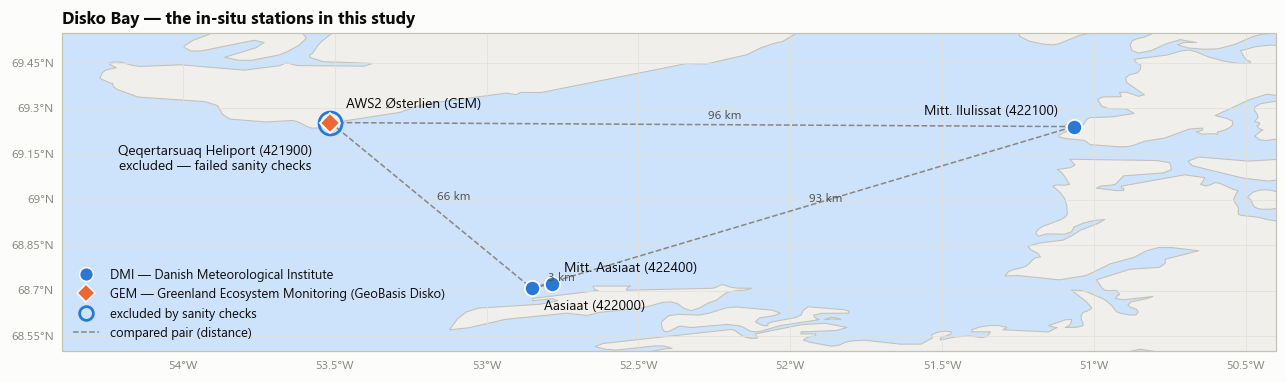

In [2]:
# ---- all stations considered in this project, on a map of Disko Bay ----
from matplotlib.lines import Line2D

MAP_STATIONS = [
    dict(key=422000, label='Aasiaat (422000)',        inst='DMI', ok=True,  dx=8,  dy=-14, ha='left'),
    dict(key=422400, label='Mitt. Aasiaat (422400)',  inst='DMI', ok=True,  dx=8,  dy=8,   ha='left'),
    dict(key=422100, label='Mitt. Ilulissat (422100)', inst='DMI', ok=True, dx=-10, dy=8,  ha='right'),
    dict(key=421900, label='Qeqertarsuaq Heliport (421900)\nexcluded — failed sanity checks',
         inst='DMI', ok=False, dx=-12, dy=-30, ha='right'),
    dict(key='GEM',  label='AWS2 Østerlien (GEM)',    inst='GEM', ok=True,  dx=10, dy=10,  ha='left'),
]
PAIR_LINES = [(422000, 422400), (422000, 422100), ('GEM', 422000), ('GEM', 422100)]
INST_COLOR = {'DMI': SERIES, 'GEM': SERIES2}
SEA, LAND = '#cde2fb', NEUTRAL
extent = [-54.4, -50.4, 68.5, 69.55]

try:   # coastline via cartopy + Natural Earth; falls back to a plain lat/lon plot without it
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    fig = plt.figure(figsize=(11.8, 6.2))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                                facecolor=LAND, edgecolor=BASELINE, lw=0.7))
    ax.set_facecolor(SEA)
    gl = ax.gridlines(draw_labels=True, lw=0.5, color=GRID, x_inline=False, y_inline=False)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 8, 'color': MUTED}
    gl.ylabel_style = {'size': 8, 'color': MUTED}
except Exception as e:
    print('coastline unavailable, plotting plain coordinates:', e)
    fig, ax = plt.subplots(figsize=(11.8, 6.2))
    ax.set_facecolor(SEA)
    ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
    ax.set_aspect(1 / np.cos(np.radians(69)))
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')

for a, b in PAIR_LINES:
    ax.plot([LOCS[a]['lon'], LOCS[b]['lon']], [LOCS[a]['lat'], LOCS[b]['lat']],
            '--', color=MUTED, lw=1, zorder=3)
    mx, my = (LOCS[a]['lon'] + LOCS[b]['lon']) / 2, (LOCS[a]['lat'] + LOCS[b]['lat']) / 2
    ax.annotate(f'{haversine_km(a, b):.0f} km', (mx, my), textcoords='offset points',
                xytext=(4, 4), fontsize=8, color=INK2, zorder=6)

for s in MAP_STATIONS:
    loc = LOCS[s['key']]
    c = INST_COLOR[s['inst']]
    marker = 'o' if s['inst'] == 'DMI' else 'D'
    if s['ok']:
        ax.plot(loc['lon'], loc['lat'], marker, color=c, ms=9 if s['inst'] == 'GEM' else 10,
                mec=SURFACE, mew=1.2, zorder=5)
    else:
        ax.plot(loc['lon'], loc['lat'], marker, mfc='none', mec=c, ms=15, mew=1.8, zorder=4)
    ax.annotate(s['label'], (loc['lon'], loc['lat']), textcoords='offset points',
                xytext=(s['dx'], s['dy']), ha=s['ha'], fontsize=9, color=INK, zorder=6)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color=SERIES, mec=SURFACE, ms=9,
           label='DMI — Danish Meteorological Institute'),
    Line2D([], [], marker='D', ls='', color=SERIES2, mec=SURFACE, ms=8,
           label='GEM — Greenland Ecosystem Monitoring (GeoBasis Disko)'),
    Line2D([], [], marker='o', ls='', mfc='none', mec=SERIES, ms=9, mew=1.8,
           label='excluded by sanity checks'),
    Line2D([], [], ls='--', color=MUTED, lw=1, label='compared pair (distance)'),
], loc='lower left', fontsize=8.5)
ax.set_title('Disko Bay — the in-situ stations in this study', loc='left')
plt.tight_layout()
plt.show()


## 3. Baseline — DMI ↔ DMI

What does agreement look like *within one network*? The ~3 km Aasiaat pair (period A) is the
ceiling — two independent stations measuring nearly the same air. The ~92 km Aasiaat↔Ilulissat
pair (periods A and B) shows how much distance alone costs per variable. Every GEM↔DMI number in
the later sections should be judged against these two rows.

,period,pair,distance_km,variable,n,bias,rmsd,r
0,A,422000<->422400,3.1,Air temp,2249,-0.20,0.44,0.994
1,A,422000<->422400,3.1,Humidity,2248,0.42,2.43,0.977
2,A,422000<->422400,3.1,Wind speed,2249,-0.16,1.17,0.889
3,A,422000<->422400,3.1,Pressure,2244,0.25,0.27,1.000
4,A,422000<->422100,92.6,Air temp,2250,-1.33,2.16,0.906
5,A,422000<->422100,92.6,Humidity,2250,5.99,13.96,0.591
6,A,422000<->422100,92.6,Wind speed,2250,0.18,3.02,0.291
7,A,422000<->422100,92.6,Pressure,2251,0.12,0.66,0.998
8,B,422000<->422100,92.6,Air temp,7651,-0.59,2.52,0.942
9,B,422000<->422100,92.6,Humidity,7656,10.90,16.83,0.650


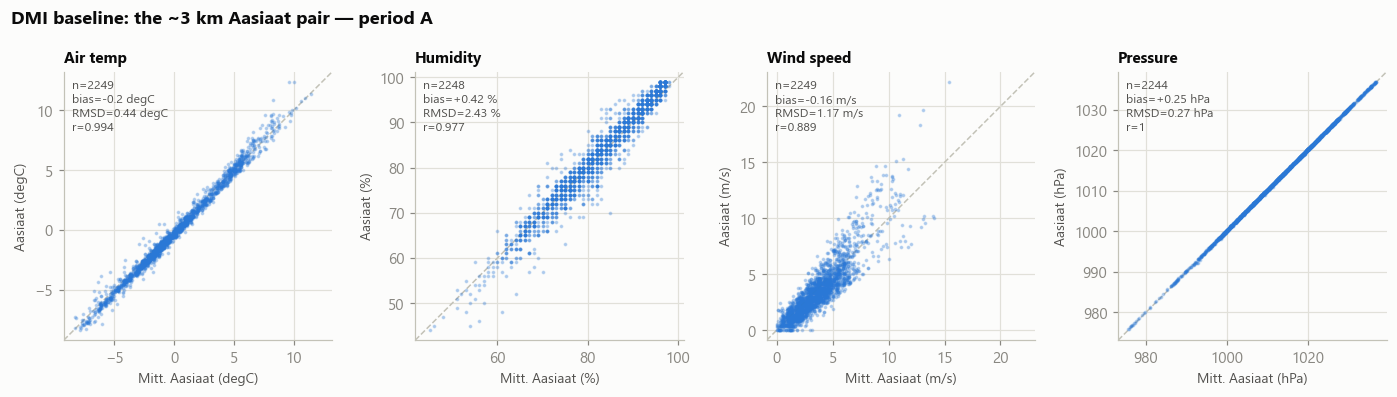

In [3]:
DMI_VARS = [('101', 'Air temp', 'degC'), ('201', 'Humidity', '%'),
            ('301', 'Wind speed', 'm/s'), ('401', 'Pressure', 'hPa')]
BASELINE_PAIRS = [('A', 422000, 422400), ('A', 422000, 422100), ('B', 422000, 422100)]

rows = []
for p, s1, s2 in BASELINE_PAIRS:
    if (p, s1) not in dmi or (p, s2) not in dmi:
        print(f'period {p}: {s1}<->{s2} not available (verdict-gated) — skipped')
        continue
    for v, vname, unit in DMI_VARS:
        _, st = compare(dmi[(p, s1)][v], dmi[(p, s2)][v], p, f'{s1}<->{s2}', vname,
                        haversine_km(s1, s2))
        rows.append(st)
display(pd.DataFrame(rows)[['period', 'pair', 'distance_km', 'variable', 'n', 'bias', 'rmsd', 'r']])

# representative scatter panel: the 3-km pair, period A
p, s1, s2 = 'A', 422000, 422400
if (p, s1) in dmi and (p, s2) in dmi:
    fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.4))
    for ax, (v, vname, unit) in zip(axes, DMI_VARS):
        both = pd.concat([dmi[(p, s1)][v].rename('a'), dmi[(p, s2)][v].rename('b')], axis=1).dropna()
        st = next(r for r in rows if r['pair'] == f'{s1}<->{s2}' and r['variable'] == vname and r['period'] == p)
        scatter_11(ax, both, st, unit, 'Mitt. Aasiaat', 'Aasiaat', vname)
    fig.suptitle('DMI baseline: the ~3 km Aasiaat pair — period A', x=0.01, ha='left',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


## 4. GEM ↔ DMI — air temperature

GEM `T_air` (3 m) vs DMI `101` (2 m) at every usable DMI station, period A. Alongside the scatter
and the daily-mean difference vs the nearest large station (Aasiaat), the mean diurnal cycles show
where the two records systematically part ways (measurement height, coastal microclimate,
fjord-vs-open-bay exposure).

,pair,distance_km,variable,n,bias,rmsd,r
0,GEM<->422000,66.1,Air temp,1764,0.48,1.64,0.923
1,GEM<->422100,96.5,Air temp,1766,-0.96,1.88,0.928
2,GEM<->422400,65.9,Air temp,1765,0.32,1.68,0.913


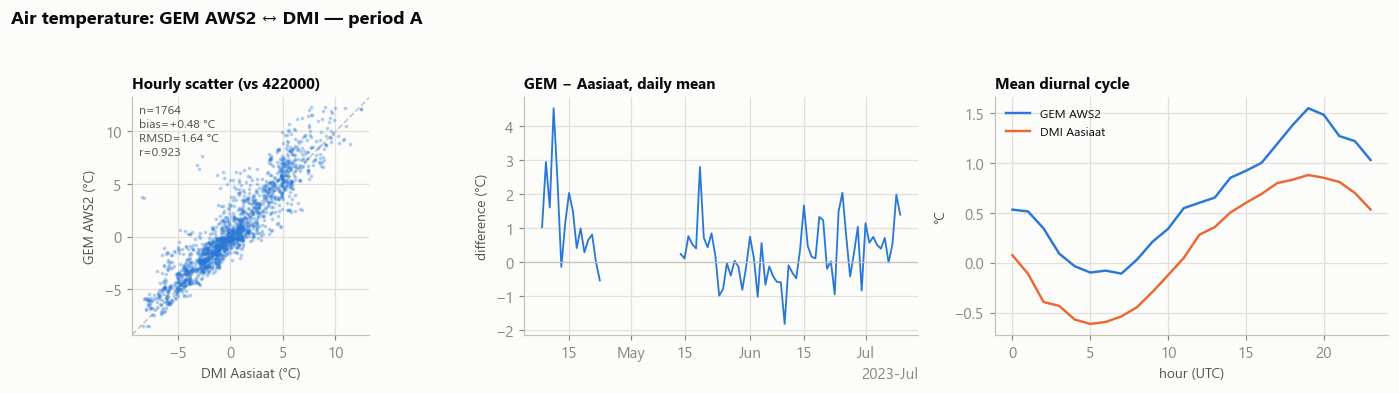

In [4]:
if 'A' not in gem_h:
    print('GEM period A not available — section skipped')
else:
    g = gem_h['A']['T_air']
    stats_by_sid = {}
    for sid in [422000, 422100, 422400]:
        if ('A', sid) not in dmi:
            continue
        both, st = compare(g, dmi[('A', sid)]['101'], 'A', f'GEM<->{sid}', 'Air temp',
                           haversine_km('GEM', sid), note='GEM 3 m vs DMI 2 m')
        stats_by_sid[sid] = (both, st)
    display(pd.DataFrame([st for _, st in stats_by_sid.values()])
            [['pair', 'distance_km', 'variable', 'n', 'bias', 'rmsd', 'r']])

    both, st = stats_by_sid[422000]
    fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.6))
    scatter_11(axes[0], both, st, '°C', 'DMI Aasiaat', 'GEM AWS2', 'Hourly scatter (vs 422000)')
    daily_diff_plot(axes[1], both, '°C', 'GEM − Aasiaat, daily mean')
    dc_gem = both['a'].groupby(both.index.hour).mean()
    dc_dmi = both['b'].groupby(both.index.hour).mean()
    axes[2].plot(dc_gem.index, dc_gem.values, color=SERIES, lw=1.6, label='GEM AWS2')
    axes[2].plot(dc_dmi.index, dc_dmi.values, color=SERIES2, lw=1.6, label='DMI Aasiaat')
    axes[2].set_xlabel('hour (UTC)', fontsize=9); axes[2].set_ylabel('°C', fontsize=9)
    axes[2].set_title('Mean diurnal cycle', loc='left', fontsize=10)
    axes[2].legend(fontsize=8)
    fig.suptitle('Air temperature: GEM AWS2 ↔ DMI — period A', x=0.01, ha='left',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


## 5. GEM ↔ DMI — relative humidity

GEM `RH` vs DMI `201` (period A).

,pair,distance_km,variable,n,bias,rmsd,r
0,GEM<->422000,66.1,Humidity,1764,-7.00,13.45,0.646
1,GEM<->422100,96.5,Humidity,1767,-1.12,12.22,0.667
2,GEM<->422400,65.9,Humidity,1765,-6.78,13.40,0.636


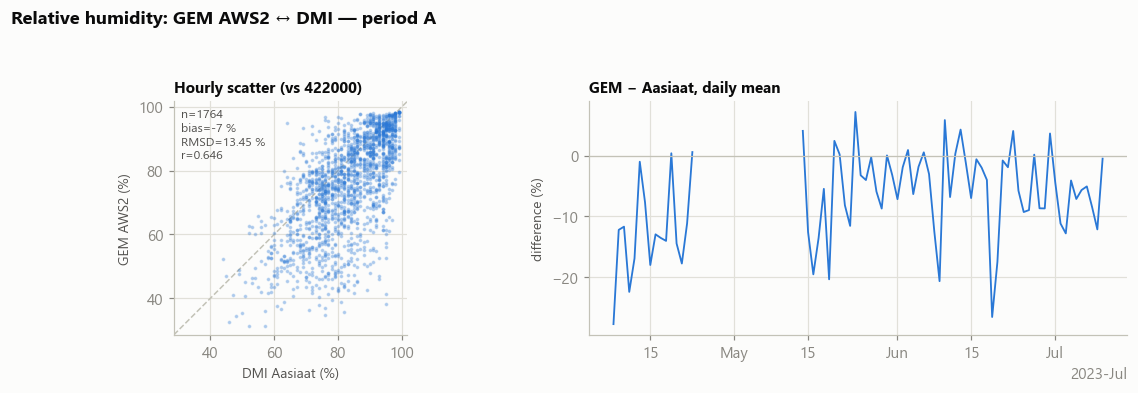

Humidity is the local variable par excellence (fog, sea breeze): expect the loosest point-to-point agreement of the thermodynamic variables at ~66 km.


In [5]:
if 'A' not in gem_h:
    print('GEM period A not available — section skipped')
else:
    g = gem_h['A']['RH']
    panels = []
    for sid in [422000, 422100, 422400]:
        if ('A', sid) not in dmi:
            continue
        both, st = compare(g, dmi[('A', sid)]['201'], 'A', f'GEM<->{sid}', 'Humidity',
                           haversine_km('GEM', sid))
        panels.append((sid, both, st))
    display(pd.DataFrame([st for _, _, st in panels])
            [['pair', 'distance_km', 'variable', 'n', 'bias', 'rmsd', 'r']])
    sid, both, st = panels[0]
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
    scatter_11(axes[0], both, st, '%', 'DMI Aasiaat', 'GEM AWS2', 'Hourly scatter (vs 422000)')
    daily_diff_plot(axes[1], both, '%', 'GEM − Aasiaat, daily mean')
    fig.suptitle('Relative humidity: GEM AWS2 ↔ DMI — period A', x=0.01, ha='left',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()
    print('Humidity is the local variable par excellence (fog, sea breeze): expect the loosest '
          'point-to-point agreement of the thermodynamic variables at ~66 km.')


## 6. GEM ↔ DMI — pressure

GEM measures **station-level** pressure at ~25 m; DMI reports **mean-sea-level** pressure, so a
constant offset (~ −1 hPa net of the ~+3 hPa altitude correction and any sensor bias) is expected
and is itself a result. The comparison removes the median offset and judges the residuals —
pressure fields are regional, so this should be the tightest cross-network agreement of all.

,pair,distance_km,variable,n,bias,rmsd,r,note
0,GEM<->422000,66.1,Pressure,1766,-0.05,0.67,0.998,station-level vs MSL; median offset -1.0 hPa r...
1,GEM<->422100,96.5,Pressure,1769,-0.05,0.63,0.998,station-level vs MSL; median offset -0.9 hPa r...
2,GEM<->422400,65.9,Pressure,1762,-0.10,0.66,0.998,station-level vs MSL; median offset -0.7 hPa r...


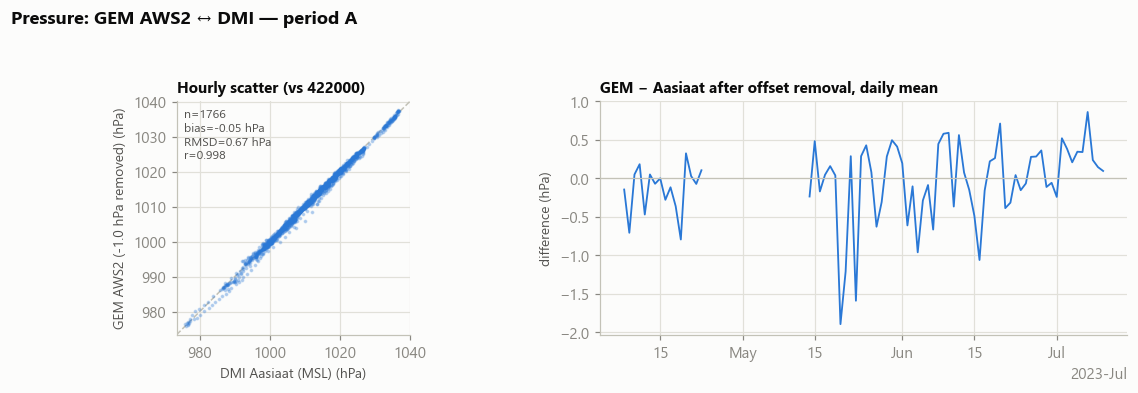

In [6]:
if 'A' not in gem_h:
    print('GEM period A not available — section skipped')
else:
    g = gem_h['A']['P_air']
    panels = []
    for sid in [422000, 422100, 422400]:
        if ('A', sid) not in dmi:
            continue
        offset = (g - dmi[('A', sid)]['401']).median()
        both, st = compare(g - offset, dmi[('A', sid)]['401'], 'A', f'GEM<->{sid}', 'Pressure',
                           haversine_km('GEM', sid),
                           note=f'station-level vs MSL; median offset {offset:+.1f} hPa removed')
        panels.append((sid, offset, both, st))
    display(pd.DataFrame([st for _, _, _, st in panels])
            [['pair', 'distance_km', 'variable', 'n', 'bias', 'rmsd', 'r', 'note']])
    sid, offset, both, st = panels[0]
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6))
    scatter_11(axes[0], both, st, 'hPa', 'DMI Aasiaat (MSL)', f'GEM AWS2 ({offset:+.1f} hPa removed)',
               'Hourly scatter (vs 422000)')
    daily_diff_plot(axes[1], both, 'hPa', 'GEM − Aasiaat after offset removal, daily mean')
    fig.suptitle('Pressure: GEM AWS2 ↔ DMI — period A', x=0.01, ha='left', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


## 7. GEM ↔ DMI — wind

Three sub-comparisons vs Aasiaat (period A), each with a built-in caveat that must be kept in mind:

- `wind_avg` ↔ `301`: GEM measures at **3.3 m**, DMI at **10 m** — surface-layer theory predicts
  GEM reads systematically lower (roughly ×0.75–0.85 over open terrain), so the *ratio* matters
  more than the bias.
- `wind_max` ↔ `305`: a 30-minute maximum of 30-second scans vs a 3-second gust — DMI's gust
  should be the higher reading by definition.
- `wind_dir` ↔ `371`: circular difference, calms excluded; 66 km apart with different local
  topography (fjord mouth vs open bay), so scatter is expected — the bulk of the distribution is
  what matters.

median GEM/DMI wind-speed ratio: 0.87  (log-profile 3.3 m/10 m over low vegetation predicts ~0.75-0.85)
wind direction: 51% of non-calm hours agree within ±45°


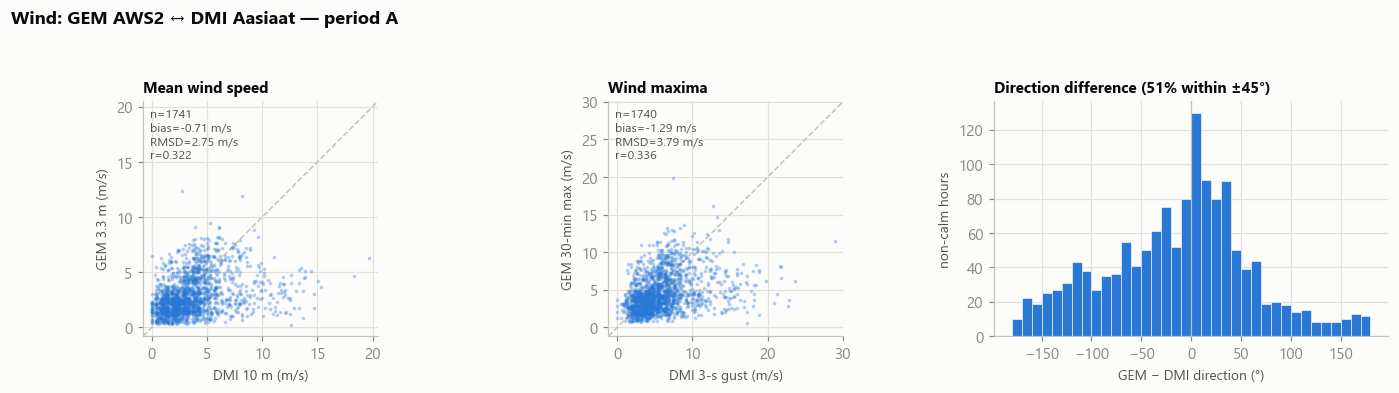

In [7]:
if 'A' not in gem_h:
    print('GEM period A not available — section skipped')
else:
    sid = 422000
    d = dmi[('A', sid)]
    g = gem_h['A']
    dist = haversine_km('GEM', sid)

    both_s, st_s = compare(g['wind_avg'], d['301'], 'A', f'GEM<->{sid}', 'Wind avg', dist,
                           note='GEM 3.3 m vs DMI 10 m — low GEM bias expected')
    ratio = (both_s['a'] / both_s['b'].replace(0, np.nan)).median()
    both_m, st_m = compare(g['wind_max'], d['305'], 'A', f'GEM<->{sid}', 'Wind max', dist,
                           note='30-min max vs 3-s gust — DMI higher by definition')
    both_d = pd.concat([g['wind_dir'].rename('a'), d['371'].rename('b'),
                        g['wind_avg'].rename('sa'), d['301'].rename('sb')], axis=1).dropna()
    both_d = both_d[(both_d['sa'] > 1) & (both_d['sb'] > 1)]   # exclude calms/near-calms
    cdiff = circular_diff_deg(both_d['a'], both_d['b'])
    within45 = float((cdiff.abs() <= 45).mean())
    CONSISTENCY_ROWS.append(dict(period='A', pair=f'GEM<->{sid}', variable='Wind dir',
                                 distance_km=round(dist, 1), n=len(both_d),
                                 bias=round(float(cdiff.mean()), 1), rmsd=round(float(cdiff.abs().mean()), 1),
                                 r=round(within45, 3),
                                 note='bias=mean circular diff, rmsd=mean |diff| (deg), r=fraction within ±45°'))
    print(f'median GEM/DMI wind-speed ratio: {ratio:.2f}  (log-profile 3.3 m/10 m over low '
          f'vegetation predicts ~0.75-0.85)')
    print(f'wind direction: {within45:.0%} of non-calm hours agree within ±45°')

    fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.6))
    scatter_11(axes[0], both_s, st_s, 'm/s', 'DMI 10 m', 'GEM 3.3 m', 'Mean wind speed')
    scatter_11(axes[1], both_m, st_m, 'm/s', 'DMI 3-s gust', 'GEM 30-min max', 'Wind maxima')
    axes[2].hist(cdiff, bins=36, range=(-180, 180), color=SERIES, edgecolor=SURFACE, lw=0.4)
    axes[2].axvline(0, color=BASELINE, lw=0.8)
    axes[2].set_xlabel('GEM − DMI direction (°)', fontsize=9)
    axes[2].set_ylabel('non-calm hours', fontsize=9)
    axes[2].set_title(f'Direction difference ({within45:.0%} within ±45°)', loc='left', fontsize=10)
    fig.suptitle('Wind: GEM AWS2 ↔ DMI Aasiaat — period A', x=0.01, ha='left', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


## 8. GEM ↔ DMI — shortwave radiation

GEM `SW_in` (Kipp&Zonen CNR4) vs DMI Aasiaat `550` (global radiation) — the only DMI radiation
record. Hour by hour the two sites see different clouds 66 km apart, so the fair test is the
**daily total**: incoming solar energy integrates over the passing cloud field and should agree
far better than the hourly scatter.

hourly r = 0.889   daily-total r = 0.874


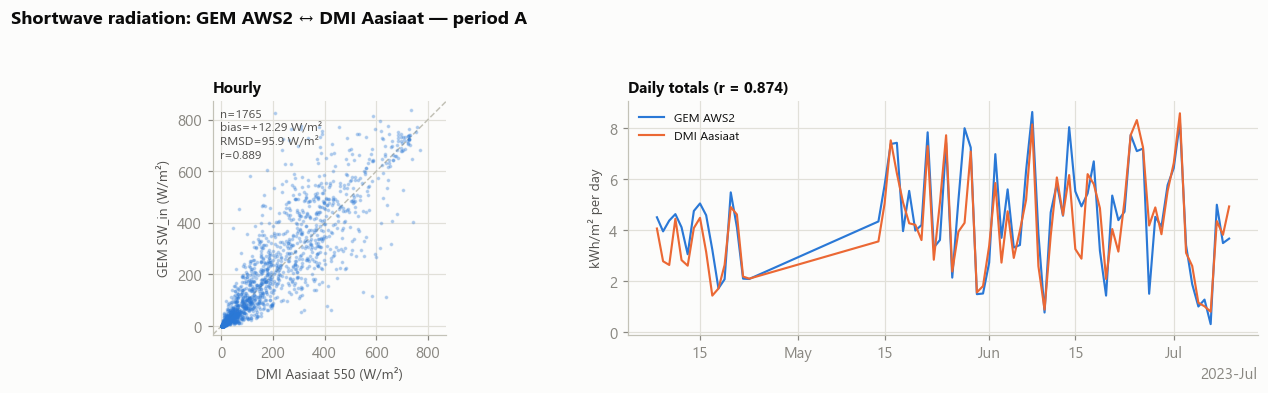

In [8]:
if 'A' not in gem_h:
    print('GEM period A not available — section skipped')
else:
    sid = 422000
    dist = haversine_km('GEM', sid)
    both_h, st_h = compare(gem_h['A']['SW_in'], dmi[('A', sid)]['550'], 'A', f'GEM<->{sid}',
                           'SW radiation', dist, note='hourly')
    # daily totals in kWh/m2 (mean W/m2 x 24 h / 1000)
    da = both_h['a'].resample('D').mean() * 24 / 1000
    db = both_h['b'].resample('D').mean() * 24 / 1000
    daily = pd.concat([da.rename('a'), db.rename('b')], axis=1).dropna()
    dd = daily['a'] - daily['b']
    r_daily = round(float(daily['a'].corr(daily['b'])), 3)
    CONSISTENCY_ROWS.append(dict(period='A', pair=f'GEM<->{sid}', variable='SW daily total',
                                 distance_km=round(dist, 1), n=len(daily),
                                 bias=round(float(dd.mean()), 2), rmsd=round(float(np.sqrt((dd**2).mean())), 2),
                                 r=r_daily, note='kWh/m2 per day'))
    print(f'hourly r = {st_h["r"]:g}   daily-total r = {r_daily:g}')

    fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.6))
    scatter_11(axes[0], both_h, st_h, 'W/m²', 'DMI Aasiaat 550', 'GEM SW_in', 'Hourly')
    axes[1].plot(daily.index, daily['a'], color=SERIES, lw=1.4, label='GEM AWS2')
    axes[1].plot(daily.index, daily['b'], color=SERIES2, lw=1.4, label='DMI Aasiaat')
    axes[1].set_ylabel('kWh/m² per day', fontsize=9)
    axes[1].set_title(f'Daily totals (r = {r_daily:g})', loc='left', fontsize=10)
    axes[1].legend(fontsize=8)
    axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
    fig.suptitle('Shortwave radiation: GEM AWS2 ↔ DMI Aasiaat — period A', x=0.01, ha='left',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()


## 9. Snow events — GEM depth changes vs Aasiaat precipitation

DMI has no snow depth, so this comparison is **event-level**: on days when GEM AWS2 records a snow
depth **rise**, did Aasiaat's gauge record snow-phase precipitation (hourly `601` in hours with
T ≤ 1.5 °C), and vice versa — matched within ±1 day. The 66 km across Disko Bay means individual
showers can hit one site and miss the other, and wind drift can raise or lower the GEM sonic
reading without snowfall (daily max wind is listed for that reason) — so the aim is *majority*
agreement, not a perfect hit rate. The late-May 2023 event is the showcase.

GEM depth-rise days (>= 2 cm): 8, matched by Aasiaat snow within +/-1 day: 7
Aasiaat snow days (>= 1 mm): 17, matched by a GEM depth rise within +/-1 day: 8


,GEM depth rise (cm),Aasiaat snow (mm),GEM daily max wind (m/s)
ts,,,
2023-04-23,10.2,9.0,9.3
2023-04-25,NaN,1.1,NaN
2023-04-26,NaN,1.0,NaN
2023-05-03,NaN,6.4,NaN
2023-05-06,NaN,1.4,NaN
2023-05-07,NaN,1.0,NaN
2023-05-18,-0.2,2.1,7.7
2023-05-20,0.6,2.1,11.5
2023-05-23,0.0,1.5,12.4


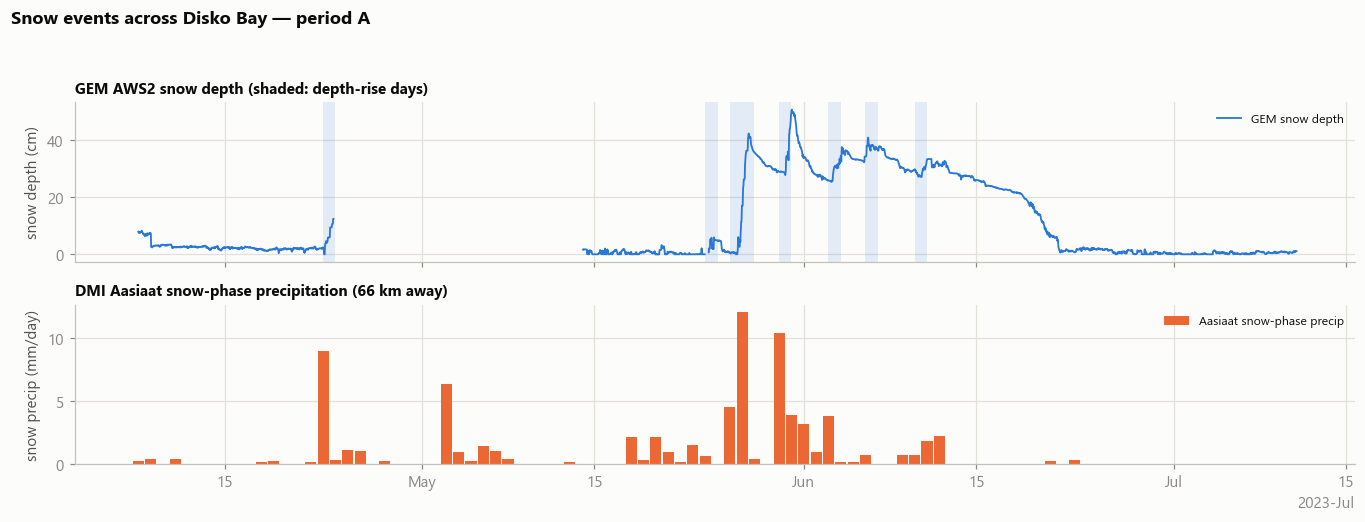

In [9]:
RISE_MIN, SNOWMM_MIN = 0.02, 1.0   # event thresholds: >=2 cm depth rise; >=1 mm snow-phase precip
if 'A' not in gem or ('A', 422000) not in dmi:
    print('GEM or DMI Aasiaat period A not available — section skipped')
else:
    gsd = gem['A']['snow_depth']
    daily_gem = pd.DataFrame({
        'rise_m': gsd.resample('D').last() - gsd.resample('D').first(),
        'wind_max': gem['A']['wind_max'].resample('D').max(),
    })
    d = dmi[('A', 422000)]
    pr = d['601'].clip(lower=0)
    snow_mm = pr.where(d['101'] <= SNOW_T, 0.0).resample('D').sum()
    daily = daily_gem.join(snow_mm.rename('aasiaat_snow_mm'), how='outer')

    gem_events = daily.index[daily['rise_m'] >= RISE_MIN]
    dmi_events = daily.index[daily['aasiaat_snow_mm'] >= SNOWMM_MIN]
    def matched(events, others):
        return [any(abs((e - o).days) <= 1 for o in others) for e in events]
    gm = matched(gem_events, dmi_events)
    dm = matched(dmi_events, gem_events)
    print(f'GEM depth-rise days (>= {RISE_MIN*100:.0f} cm): {len(gem_events)}, '
          f'matched by Aasiaat snow within +/-1 day: {sum(gm)}')
    print(f'Aasiaat snow days (>= {SNOWMM_MIN:g} mm): {len(dmi_events)}, '
          f'matched by a GEM depth rise within +/-1 day: {sum(dm)}')
    ev = daily.loc[sorted(set(gem_events) | set(dmi_events))].copy()
    ev['rise_cm'] = (ev['rise_m'] * 100).round(1)
    display(ev[['rise_cm', 'aasiaat_snow_mm', 'wind_max']].rename(
        columns={'aasiaat_snow_mm': 'Aasiaat snow (mm)', 'wind_max': 'GEM daily max wind (m/s)',
                 'rise_cm': 'GEM depth rise (cm)'}))
    n_events = len(set(gem_events) | set(dmi_events))
    CONSISTENCY_ROWS.append(dict(period='A', pair='GEM<->422000', variable='Snow events',
                                 distance_km=round(haversine_km('GEM', 422000), 1), n=n_events,
                                 bias=np.nan, rmsd=np.nan,
                                 r=round((sum(gm) + sum(dm)) / max(len(gm) + len(dm), 1), 3),
                                 note=f'r = fraction of events matched within +/-1 day '
                                      f'({sum(gm)}/{len(gm)} GEM rises, {sum(dm)}/{len(dm)} Aasiaat snow days)'))

    fig, axes = plt.subplots(2, 1, figsize=(12.5, 4.8), sharex=True)
    axes[0].plot(gsd.index, gsd.values * 100, color=SERIES, lw=1.2, label='GEM snow depth')
    for e in gem_events:
        axes[0].axvspan(e, e + pd.Timedelta(days=1), color=SERIES, alpha=0.12, lw=0)
    axes[0].set_ylabel('snow depth (cm)')
    axes[0].legend(loc='upper right', fontsize=8)
    axes[0].set_title('GEM AWS2 snow depth (shaded: depth-rise days)', loc='left', fontsize=10)
    axes[1].bar(snow_mm.index, snow_mm.values, width=0.9, color=SERIES2, lw=0,
                label='Aasiaat snow-phase precip')
    axes[1].set_ylabel('snow precip (mm/day)')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].set_title('DMI Aasiaat snow-phase precipitation (66 km away)', loc='left', fontsize=10)
    axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(axes[1].xaxis.get_major_locator()))
    fig.suptitle('Snow events across Disko Bay — period A', x=0.01, ha='left', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


## 10. Consistency matrix

Every comparison above, in one table (`results/cross_source_consistency.csv`) and one correlation
heatmap. Special rows: *Wind dir* stores the fraction of non-calm hours within ±45° in `r`;
*Snow events* stores the event match rate in `r`.

Wrote C:\Users\marti\Desktop\DMI stations\results\cross_source_consistency.csv (27 comparisons)


,period,pair,variable,distance_km,n,bias,rmsd,r,note
0,A,422000<->422400,Air temp,3.1,2249,-0.20,0.44,0.994,
1,A,422000<->422400,Humidity,3.1,2248,0.42,2.43,0.977,
2,A,422000<->422400,Wind speed,3.1,2249,-0.16,1.17,0.889,
3,A,422000<->422400,Pressure,3.1,2244,0.25,0.27,1.000,
4,A,422000<->422100,Air temp,92.6,2250,-1.33,2.16,0.906,
5,A,422000<->422100,Humidity,92.6,2250,5.99,13.96,0.591,
6,A,422000<->422100,Wind speed,92.6,2250,0.18,3.02,0.291,
7,A,422000<->422100,Pressure,92.6,2251,0.12,0.66,0.998,
8,B,422000<->422100,Air temp,92.6,7651,-0.59,2.52,0.942,
9,B,422000<->422100,Humidity,92.6,7656,10.90,16.83,0.650,


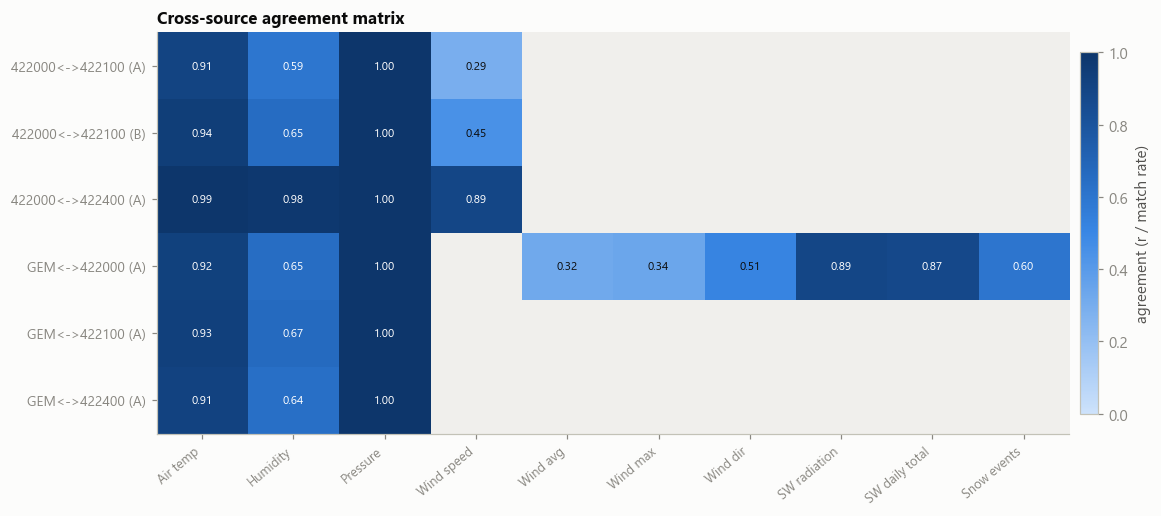

In [10]:
consistency = pd.DataFrame(CONSISTENCY_ROWS)[
    ['period', 'pair', 'variable', 'distance_km', 'n', 'bias', 'rmsd', 'r', 'note']]
consistency.to_csv(RESULTS_DIR / 'cross_source_consistency.csv', index=False)
print(f'Wrote {RESULTS_DIR / "cross_source_consistency.csv"} ({len(consistency)} comparisons)')
display(consistency)

# heatmap of r: pair (period) x variable
piv = consistency.pivot_table(index=consistency['pair'] + ' (' + consistency['period'] + ')',
                              columns='variable', values='r', aggfunc='first')
col_order = [c for c in ['Air temp', 'Humidity', 'Pressure', 'Wind speed', 'Wind avg', 'Wind max',
                         'Wind dir', 'SW radiation', 'SW daily total', 'Snow events'] if c in piv.columns]
piv = piv[col_order]
fig, ax = plt.subplots(figsize=(11.5, 0.5 * len(piv) + 1.8))
cmap = CMAP_SEQ.copy(); cmap.set_bad(NEUTRAL)
im = ax.imshow(np.ma.masked_invalid(piv.values), cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(piv.columns)), piv.columns, rotation=40, ha='right', fontsize=8.5)
ax.set_yticks(range(len(piv.index)), piv.index, fontsize=9)
ax.grid(False)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        val = piv.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5,
                    color='#ffffff' if val > 0.55 else INK)
cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.01)
cbar.set_label('agreement (r / match rate)', color=INK2)
ax.set_title('Cross-source agreement matrix', loc='left')
plt.tight_layout()
plt.show()


In [11]:
# ---- positive controls ----
assert (RESULTS_DIR / 'cross_source_consistency.csv').exists()
assert len(consistency) >= 15, f'expected a full matrix, got {len(consistency)} comparisons'
assert not any(('GEM' in r['pair']) and (r['period'] == 'B') for r in CONSISTENCY_ROWS), \
    'GEM must not appear in period B comparisons (no published 2025 data)'
press = consistency[consistency['variable'] == 'Pressure']
assert (press['r'] > 0.9).all(), 'pressure should correlate above 0.9 across all pairs'
gem_a = consistency[consistency['pair'].str.startswith('GEM') & (consistency['variable'] == 'Air temp')]
assert (gem_a['n'] > 500).all(), 'GEM temperature comparisons should have substantial overlap'
print('All positive-control assertions passed.')


All positive-control assertions passed.


## 11. How to use this downstream

1. **Trust hierarchy for EO/model validation:** variables whose GEM↔DMI agreement sits between
   the 3-km and 92-km DMI baselines are network-consistent — use either source (or both) as ground
   truth at their own grid cell. Variables with known structural offsets (pressure level, wind
   measurement height) are fine once the documented offset/ratio is applied.
2. **Snowfall rate specifically:** the event-level match between GEM depth rises and Aasiaat
   snow-phase precipitation sets the *expectation* for how well any EO/model snowfall field can
   agree with a point measurement across ~66 km — do not demand more of the satellite than the
   two ground stations achieve between themselves.
3. `results/cross_source_consistency.csv` holds every number in this notebook; join it with the
   sanity verdicts when documenting the validation setup.
4. When GEM publishes 2025, re-run `gem_sanity_checks.ipynb` and then this notebook — the GEM
   sections extend to period B automatically.